In [30]:
#cspell:words backtest DEMA
import config as cfg
import yfinance as yf
import pandas as pd
import numpy as np
import indicators as ind
import data
from data import df
import matplotlib.pyplot as plt

[*********************100%***********************]  1 of 1 completed


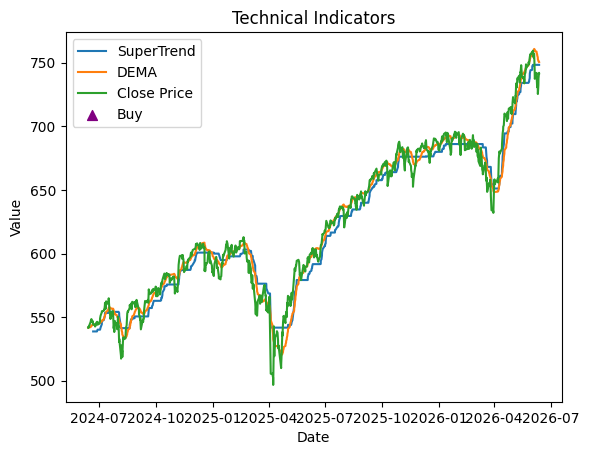

In [34]:
import importlib

#cspell:words backtest DEMA xlabel ylabel

importlib.reload(cfg)
importlib.reload(ind)
importlib.reload(data)
indicator_df = pd.DataFrame({
    'ATR': ind.ATR(df).calculate(),
    'SuperTrend': ind.SuperTrend(df).calculate(),
    'ADX': ind.ADX(df).calculate(),
    'RSI': ind.RSI(df).calculate(),
    'DEMA': ind.DEMA(df).calculate(),
}, index=df.index).interpolate(method='time', limit_area='inside')

plt.plot(indicator_df.loc[:, ['SuperTrend', 'DEMA']], label=['SuperTrend', 'DEMA'])
plt.plot(df['Close'], label='Close Price')
plt.title("Technical Indicators")
plt.xlabel("Date")
plt.ylabel("Value")
mask = (
    (df["Close"] > indicator_df["DEMA"]) &
    (indicator_df["RSI"] < 30) &
    (indicator_df["ADX"] > 25) &
    (indicator_df["ATR"] > 0) &
    (indicator_df["SuperTrend"] > df["Close"])
).fillna(False)

plt.scatter(df.index[mask], df.loc[mask, "Close"], marker='^', color='purple', s=50, label='Buy')
plt.legend()
plt.show()